In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from catboost import CatBoostRegressor
from lightgbm import LGBMRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.exceptions import ConvergenceWarning
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import cross_val_score, GridSearchCV

warnings.simplefilter(action='ignore', category=FutureWarning)
warnings.simplefilter('ignore', category=ConvergenceWarning)

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: '%.4f' % x)

In [2]:
df = pd.read_pickle("data/df_step3.pkl")

In [3]:
train_df = df[df['SalePrice'].notnull()]
test_df  = df[df['SalePrice'].isnull()]

# Log dönüşümü — SalePrice 
y = np.log1p(train_df['SalePrice'])
X = train_df.drop(["Id", "SalePrice"], axis=1)

print(f"Train shape : {X.shape}")
print(f"Test  shape : {test_df.shape}")

Train shape : (1460, 193)
Test  shape : (1459, 195)


In [4]:
models = [
    ('LR',       LinearRegression()),
    ('Ridge',    Ridge()),
    ('Lasso',    Lasso()),
    ('KNN',      KNeighborsRegressor()),
    ('CART',     DecisionTreeRegressor()),
    ('RF',       RandomForestRegressor(random_state=46)),
    ('GBM',      GradientBoostingRegressor(random_state=46)),
    ('XGBoost',  XGBRegressor(objective='reg:squarederror', random_state=46, verbosity=0)),
    ('LightGBM', LGBMRegressor(random_state=46, verbosity=-1)),
    ('CatBoost', CatBoostRegressor(random_state=46, verbose=False)),
]

results = []
for name, model in models:
    rmse = np.mean(np.sqrt(-cross_val_score(model, X, y, cv=5, scoring="neg_mean_squared_error")))
    results.append((name, round(rmse, 4)))
    print(f"RMSE: {rmse:.4f}  ({name})")

results_df = pd.DataFrame(results, columns=["Model", "RMSE"]).sort_values("RMSE")
print("\n", results_df.to_string(index=False))

RMSE: 0.1373  (LR)
RMSE: 0.1288  (Ridge)
RMSE: 0.1785  (Lasso)
RMSE: 0.2363  (KNN)
RMSE: 0.2013  (CART)
RMSE: 0.1382  (RF)
RMSE: 0.1292  (GBM)
RMSE: 0.1408  (XGBoost)
RMSE: 0.1341  (LightGBM)
RMSE: 0.1212  (CatBoost)

    Model   RMSE
CatBoost 0.1212
   Ridge 0.1288
     GBM 0.1292
LightGBM 0.1341
      LR 0.1373
      RF 0.1382
 XGBoost 0.1408
   Lasso 0.1785
    CART 0.2013
     KNN 0.2363


In [5]:
# ---- LightGBM ----
lgbm_params = {
    "learning_rate"  : [0.01, 0.05, 0.1],
    "n_estimators"   : [500, 1000, 1500],
    "max_depth"      : [3, 5, -1],
    "num_leaves"     : [31, 50],
    "subsample"      : [0.8, 1.0],
    "colsample_bytree": [0.7, 1.0],
}

lgbm_gs = GridSearchCV(
    LGBMRegressor(random_state=46, verbosity=-1),
    lgbm_params,
    cv=5,
    scoring="neg_mean_squared_error",
    n_jobs=-1,
    verbose=1
).fit(X, y)

print("LightGBM — Best RMSE :", round(np.sqrt(-lgbm_gs.best_score_), 4))
print("LightGBM — Best Params:", lgbm_gs.best_params_)

Fitting 5 folds for each of 216 candidates, totalling 1080 fits
LightGBM — Best RMSE : 0.129
LightGBM — Best Params: {'colsample_bytree': 0.7, 'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 500, 'num_leaves': 31, 'subsample': 0.8}


In [6]:
# ---- GradientBoosting ----
gbm_params = {
    "learning_rate": [0.01, 0.05, 0.1],
    "n_estimators" : [200, 500, 1000],
    "max_depth"    : [3, 5],
    "subsample"    : [0.8, 1.0],
}

gbm_gs = GridSearchCV(
    GradientBoostingRegressor(random_state=46),
    gbm_params,
    cv=5,
    scoring="neg_mean_squared_error",
    n_jobs=-1,
    verbose=1
).fit(X, y)

print("GBM — Best RMSE :", round(np.sqrt(-gbm_gs.best_score_), 4))
print("GBM — Best Params:", gbm_gs.best_params_)

Fitting 5 folds for each of 36 candidates, totalling 180 fits
GBM — Best RMSE : 0.1263
GBM — Best Params: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 500, 'subsample': 0.8}


In [7]:
# ---- XGBoost ----
xgb_params = {
    "learning_rate"   : [0.01, 0.05, 0.1],
    "n_estimators"    : [500, 1000],
    "max_depth"       : [3, 5, 7],
    "subsample"       : [0.8, 1.0],
    "colsample_bytree": [0.7, 1.0],
}

xgb_gs = GridSearchCV(
    XGBRegressor(objective='reg:squarederror', random_state=46, verbosity=0),
    xgb_params,
    cv=5,
    scoring="neg_mean_squared_error",
    n_jobs=-1,
    verbose=1
).fit(X, y)

print("XGBoost — Best RMSE :", round(np.sqrt(-xgb_gs.best_score_), 4))
print("XGBoost — Best Params:", xgb_gs.best_params_)

Fitting 5 folds for each of 72 candidates, totalling 360 fits
XGBoost — Best RMSE : 0.126
XGBoost — Best Params: {'colsample_bytree': 0.7, 'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 500, 'subsample': 0.8}


In [8]:
# ---- CatBoost ----
#best score (0.1224), We're improving it further with tuning
catboost_params = {
    "learning_rate": [0.01, 0.05, 0.1],
    "iterations"   : [500, 1000],
    "depth"        : [4, 6, 8],
    "l2_leaf_reg"  : [1, 3, 5],
    "subsample"    : [0.8, 1.0],
}

cat_gs = GridSearchCV(
    CatBoostRegressor(random_state=46, verbose=False),
    catboost_params,
    cv=5,
    scoring="neg_mean_squared_error",
    n_jobs=-1,
    verbose=1
).fit(X, y)

print("CatBoost — Best RMSE :", round(np.sqrt(-cat_gs.best_score_), 4))
print("CatBoost — Best Params:", cat_gs.best_params_)

Fitting 5 folds for each of 108 candidates, totalling 540 fits


C:\ProgramData\anaconda3\Lib\site-packages\sklearn\model_selection\_validation.py:528: FitFailedWarning: 
3 fits failed out of a total of 540.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
1 fits failed with the following error:
Traceback (most recent call last):
  File "C:\ProgramData\anaconda3\Lib\site-packages\sklearn\model_selection\_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
    ~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\ProgramData\anaconda3\Lib\site-packages\catboost\core.py", line 6178, in fit
    return self._fit(X, y, cat_features, text_features, embedding_features, None, graph, sample_weight, None, None, None, None, baseline,
           ~~~~~~~~~^^^^^^^^^^^^^^^

CatBoost — Best RMSE : 0.1211
CatBoost — Best Params: {'depth': 6, 'iterations': 1000, 'l2_leaf_reg': 3, 'learning_rate': 0.05, 'subsample': 0.8}


In [9]:
from sklearn.ensemble import VotingRegressor

best_lgbm = lgbm_gs.best_estimator_
best_gbm  = gbm_gs.best_estimator_
best_xgb  = xgb_gs.best_estimator_
best_cat  = cat_gs.best_estimator_


print("Tuned model RMSE:")
for name, gs in [('LightGBM', lgbm_gs), ('GBM', gbm_gs), ('XGBoost', xgb_gs), ('CatBoost', cat_gs)]:
    print(f"  {name:<12}: {round(np.sqrt(-gs.best_score_), 4)}")


voting_model = VotingRegressor(estimators=[
    ('lgbm', best_lgbm),
    ('gbm',  best_gbm),
    ('xgb',  best_xgb),
    ('cat',  best_cat),
])

voting_model.fit(X, y)

voting_rmse = np.mean(np.sqrt(-cross_val_score(
    voting_model, X, y, cv=5, scoring="neg_mean_squared_error"
)))
print(f"\nVoting Ensemble CV RMSE: {voting_rmse:.4f}")

Tuned model RMSE:
  LightGBM    : 0.129
  GBM         : 0.1263
  XGBoost     : 0.126
  CatBoost    : 0.1211

Voting Ensemble CV RMSE: 0.1222


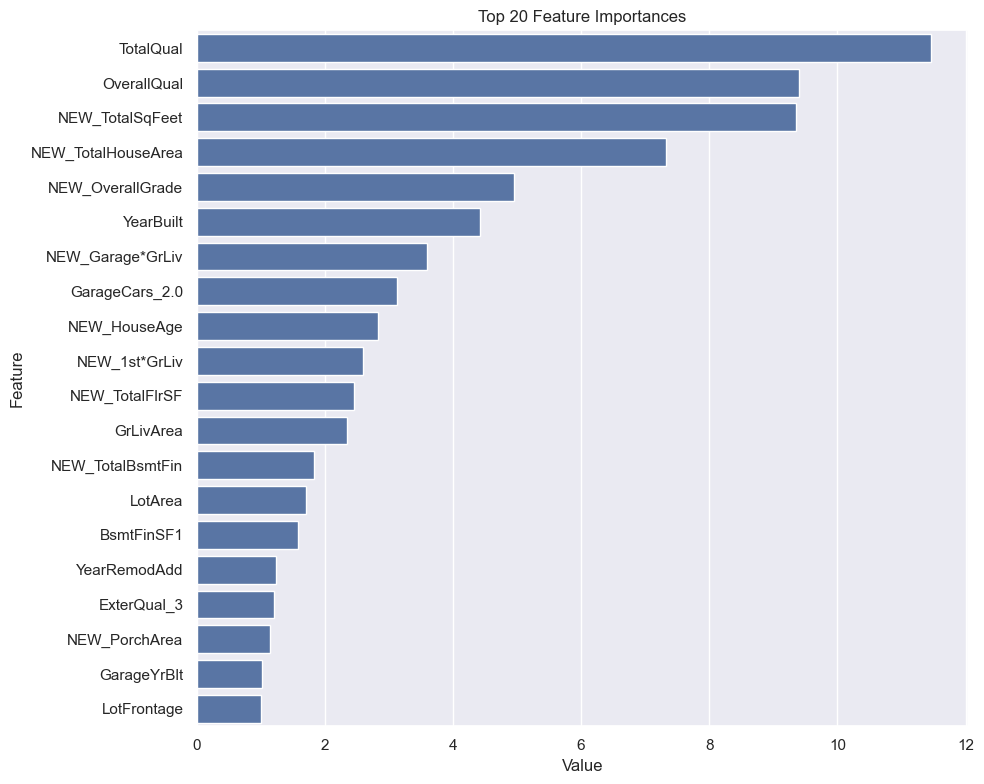

In [11]:
def plot_importance(model, features, num=20, save=False):
    feature_imp = pd.DataFrame({
        "Value"  : model.feature_importances_,
        "Feature": features.columns
    })
    plt.figure(figsize=(10, 8))
    sns.set(font_scale=1)
    sns.barplot(
        x="Value", y="Feature",
        data=feature_imp.sort_values(by="Value", ascending=False).head(num)
    )
    plt.title(f"Top {num} Feature Importances")
    plt.tight_layout()
    if save:
        plt.savefig("importances.png")
    plt.show()

# Final model (CatBoost) feature importance
plot_importance(best_cat, X, num=20)

In [ ]:
X_test_kaggle = test_df.drop(["Id", "SalePrice"], axis=1)

# Predict & log 
preds = np.expm1(voting_model.predict(X_test_kaggle))

submission = pd.DataFrame({
    "Id"       : test_df["Id"].astype(int),
    "SalePrice": preds
})
